#**Jacobi Iterative Method:**

###**Definition:**

The Jacobi Iterative Method is an iterative numerical method used to solve a system of linear equations:
       
       Ax=b

It finds the solution by repeatedly updating each unknown values using the previous iteration.The matrix is to be **diagonally dominant or symmetric positive definite** then the system should be convergent.Neither the condition holds then the system not gurantee to be convergent.

It is particularly useful for large systems where direct methods such as Gaussian elimination or LU decomposition may be expensive.

###**Applications:**

**Solving Large Sparse Linear Systems**

Common in finite element analysis (FEA),  finite difference methods (FDM), and finite volume methods (FVM) for engineering simulations.
Example: Structural analysis of bridges, aircraft, or buildings.

**Numerical Solutions of PDEs**

Solves discretized Laplace, Poisson, and heat equations.
Example: Temperature distribution in a plate.

**Computational Fluid Dynamics (CFD)**

Used to solve discretized Navier–Stokes equations for fluid flow simulations.For exxample; Weather prediction, aerodynamics, and heat transfer problems.



### **Formula:**

Consider the system:

a11*x1 + a12*x2 + ... + a1nxn = b1

a21*x1 + a22*x2 + ... + a2nxn = b2

...

an1*x1 + an2*x2 + ... + annxn = bn

For the i-th equation:

xi^(k+1) = (bi - sum(aij*xj^(k))) / aii

where:

- xi^(k) = current value of xi
- xi^(k+1) = updated value of xi
- aij = coefficient of matrix A
- bi = element of vector b

Important Point:

In the Jacobi Method, all new values are calculated using only the values from the previous iteration.

###  **Example:**

Consider the system:

4x + y = 9

x + 3y = 7

Rewrite the equations:

x = (9 - y) / 4

y = (7 - x) / 3

Therefore:

x^(k+1) = (9 - y^(k)) / 4

y^(k+1) = (7 - x^(k)) / 3

Initial guess:

x^(0) = 0
y^(0) = 0

Iteration 1:

x^(1) = (9 - 0) / 4 = 2.25

y^(1) = (7 - 0) / 3 = 2.3333

Iteration 2:

x^(2) = (9 - 2.3333) / 4 = 1.6667

y^(2) = (7 - 2.25) / 3 = 1.5833

The process continues until the solution converges.

Exact solution:

x = 2
y = 1.6667

Therefore, Jacobi gradually approaches:

x ≈ 2
y ≈ 1.6667
```

###**Algorithm:**

1. Start with the matrix A, vector b, and an initial guess x.

2. Set the maximum number of iterations and tolerance.

3. For each iteration:
   - Calculate each new variable using the old values.
   - Store the new values in a new vector.

4. Calculate the error between the new and old values.

5. If the error is smaller than the tolerance, stop the iteration.

6. Otherwise, use the new values as the old values and continue.

7. Return the final solution.



In [ ]:
import numpy as np
def jacobi(A,b,x0,max_iter=100,tol=1e-10):
  n=len(b)
  x=x0.copy()
  for iteration in range(max_iter):
    x_new= np.zeros(n)
    for i in range(n):
      sum_values=0
      for j in range(n):
        if j!=i:
          sum_values+=A[i,j]*x[j]
        x_new[i]=(b[i]-sum_values)/A[i,i]
      error=np.linalg.norm(x_new-x)
      if error<tol:
        return x_new
      x=x_new
  return x,max_iter

### **Question No 01:**

Implement the **Jacobi Iterative Method** in Python to solve a system of linear equations (Ax=b). The program should use an initial guess, iteratively update the solution until the specified tolerance is reached or the maximum number of iterations is exceeded, and verify the final solution by calculating the residual error (||Ax-b||).


In [ ]:
import numpy as np
def jacobi(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    for iteration in range(max_iter):
        x_new = np.zeros(n)
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            if A[i, i] == 0:
                raise ValueError("Zero diagonal element")
            x_new[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x_new - x)
        print("Iteration:", iteration + 1)
        print("x =", x_new)
        print("Error =", error)
        print()
        if error < tol:
            return x_new, iteration + 1
        x = x_new
    return x, max_iter

A = np.array([
    [4, 1],
    [1, 3]], dtype=float)
b = np.array([9, 7], dtype=float)
x0 = np.array([0, 0], dtype=float)
x,iterations = jacobi(A, b, x0)
print("Final Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)

Iteration: 1
x = [2.25       2.33333333]
Error = 3.2414417231294546

Iteration: 2
x = [1.66666667 1.58333333]
Error = 0.9501461875826153

Iteration: 3
x = [1.85416667 1.77777778]
Error = 0.2701201435941215

Iteration: 4
x = [1.80555556 1.71527778]
Error = 0.07917884896521812

Iteration: 5
x = [1.82118056 1.73148148]
Error = 0.022510011966176937

Iteration: 6
x = [1.81712963 1.72627315]
Error = 0.0065982374137683476

Iteration: 7
x = [1.81843171 1.72762346]
Error = 0.0018758343305148074

Iteration: 8
x = [1.81809414 1.72718943]
Error = 0.000549853117813964

Iteration: 9
x = [1.81820264 1.72730195]
Error = 0.00015631952754288826

Iteration: 10
x = [1.81817451 1.72726579]
Error = 4.582109315131459e-05

Iteration: 11
x = [1.81818355 1.72727516]
Error = 1.3026627295371507e-05

Iteration: 12
x = [1.81818121 1.72727215]
Error = 3.8184244293021825e-06

Iteration: 13
x = [1.81818196 1.72727293]
Error = 1.0855522746528245e-06

Iteration: 14
x = [1.81818177 1.72727268]
Error = 3.18202035940716e-0

### **Question No 02:**

Implement and analyze the Jacobi iterative method in Python for solving a system of linear equations (Ax=b). The program should iteratively compute the solution from an initial guess, monitor the error at each iteration, terminate when the specified convergence tolerance is achieved, verify the final solution using the residual error (||Ax-b||), and visualize the convergence behavior through error-versus-iteration and solution-values-versus-iteration plots.


Iteration: 1
x = [1.2 1.3 1.4]
Error = 2.2561028345356955

Iteration: 2
x = [0.93 0.92 0.9 ]
Error = 0.683593446428504

Iteration: 3
x = [1.018 1.024 1.03 ]
Error = 0.18830825791770264

Iteration: 4
x = [0.9946 0.9934 0.9916]
Error = 0.05439191116333385

Iteration: 5
x = [1.0015  1.00192 1.0024 ]
Error = 0.015389619878346654

Iteration: 6
x = [0.999568 0.99946  0.999316]
Error = 0.004392639297734442

Iteration: 7
x = [1.0001224 1.0001548 1.0001944]
Error = 0.0012496771423051811

Iteration: 8
x = [0.99996508 0.99995608 0.99994456]
Error = 0.00035589218367362835

Iteration: 9
x = [1.00000994 1.00001253 1.00001577]
Error = 0.00010133615694325373

Iteration: 10
x = [0.99999717 0.99999644 0.99999551]
Error = 2.885156883110338e-05

Iteration: 11
x = [1.00000081 1.00000102 1.00000128]
Error = 8.215520460082777e-06

Iteration: 12
x = [0.99999977 0.99999971 0.99999964]
Error = 2.3391109035268016e-06

Iteration: 13
x = [1.00000007 1.00000008 1.0000001 ]
Error = 6.660406272360966e-07

Iteration: 

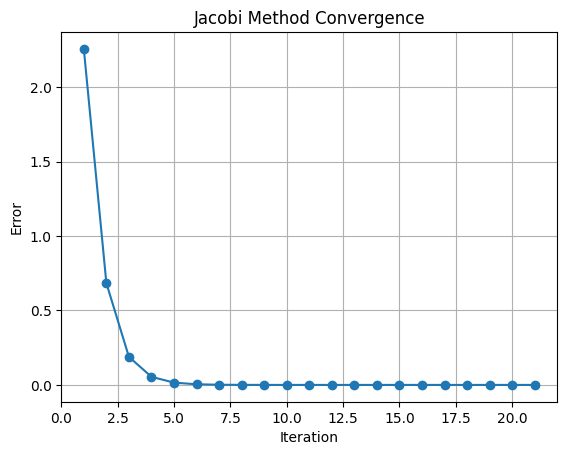

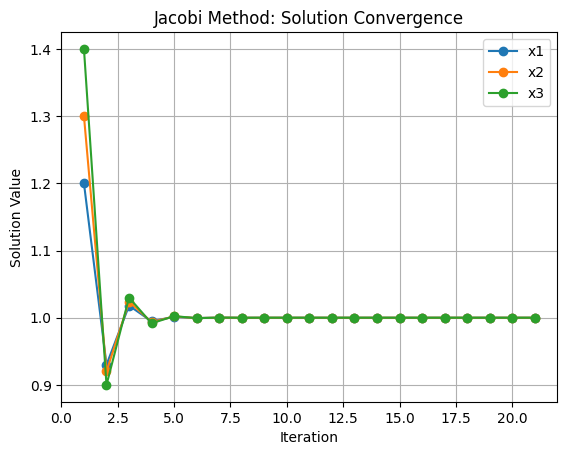

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def jacobi(A, b, x0, max_iter=100, tol=1e-10):
    n = len(b)
    x = x0.copy()
    errors=[]
    solutions=[]
    for iteration in range(max_iter):
        x_new = np.zeros(n)
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            if A[i, i] == 0:
                raise ValueError("Zero diagonal element")
            x_new[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x_new - x)
        errors.append(error)
        solutions.append(x_new.copy())
        print("Iteration:", iteration + 1)
        print("x =", x_new)
        print("Error =", error)
        print()
        if error < tol:
            return x_new, iteration + 1,errors,solutions
        x = x_new
    return x, max_iter,errors,solutions

A = np.array([
    [10,1,1],
    [2,10,1],
    [2,2,10]], dtype=float)
b = np.array([12,13,14], dtype=float)
x0 = np.array([0,0,0], dtype=float)
x,iterations,errors,solutions = jacobi(A, b, x0)
print("Final Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)
solutions=np.array(solutions)

#  Error vs Iteration(how quickly the Jacobi method is converging.)
plt.figure()
plt.plot( range(1, len(errors) + 1), errors, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Jacobi Method Convergence")
plt.grid()

plt.show()
#  Solution Values vs Iteration(how each unknown approaches its final solution.)
plt.figure()
plt.plot(range(1, len(solutions) + 1),solutions[:, 0],marker='o',label='x1')
plt.plot( range(1, len(solutions) + 1), solutions[:, 1],marker='o',label='x2')
plt.plot(range(1, len(solutions) + 1),solutions[:, 2],marker='o',label='x3')
plt.xlabel("Iteration")
plt.ylabel("Solution Value")
plt.title("Jacobi Method: Solution Convergence")
plt.legend()
plt.grid()
plt.show()

### **Jacobi Method with the diagonal dominance:**

###   What is diagnolly dominant matrix?

"The absolute value of the diagonal element must be greater than the sum of the absolute values of all the other elements in that row."

### **Question No 03:**

A water distribution system is modeled by a set of linear equations representing the flow rates and pressure adjustments at three connected junctions. Use the Jacobi iterative method in Python to determine the unknown system variables from the given equations. Before solving, verify whether the coefficient matrix is strictly diagonally dominant to assess the expected convergence of the method. Track the error and solution values at each iteration, verify the final solution using the residual error, and visualize the convergence behavior through appropriate plots.


Diagonal Dominance Check:
Matrix is strictly diagonally dominant.
Iteration: 1
x= [0.5 0.4 0.3]
Error= 0.7071067811865476

Iteration: 2
x= [0.43 0.27 0.12]
Error= 0.23280893453645632

Iteration: 3
x= [0.461 0.302 0.16 ]
Error= 0.059874869519690815

Iteration: 4
x= [0.4538 0.2918 0.1474]
Error= 0.017738094598913366

Iteration: 5
x= [0.45608 0.2945  0.15088]
Error= 0.004959717733903795

Iteration: 6
x= [0.455462 0.293696 0.149884]
Error= 0.0014213922752006308

Iteration: 7
x= [0.455642  0.2939192 0.1501684]
Error= 0.00040385839102342604

Iteration: 8
x= [0.45559124 0.29385476 0.15008776]
Error= 0.00011502999956534381

Iteration: 9
x= [0.45560575 0.29387298 0.1501108 ]
Error= 3.275891206981892e-05

Iteration: 10
x= [0.45560162 0.29386777 0.15010426]
Error= 9.324872854886418e-06

Iteration: 11
x= [0.4556028  0.29386925 0.15010612]
Error= 2.655708361100484e-06

Iteration: 12
x= [0.45560246 0.29386883 0.15010559]
Error= 7.560453277572825e-07

Iteration: 13
x= [0.45560256 0.29386895 0.1501057

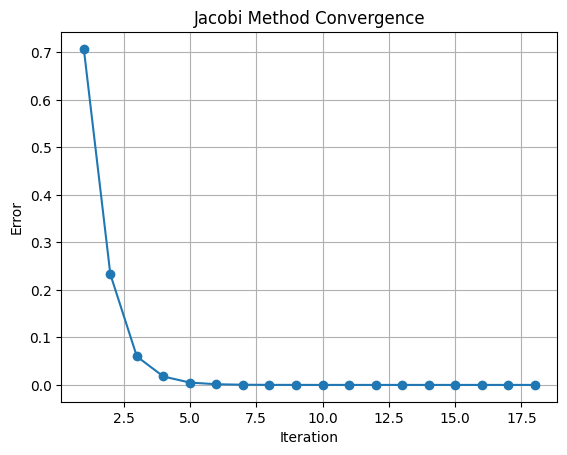

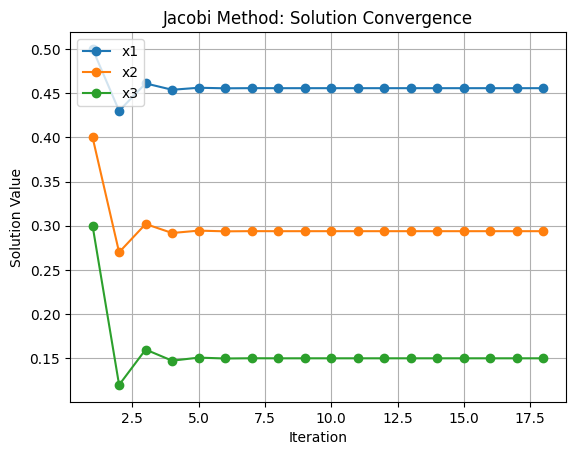

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def diagonally_dominant(A):
  n=len(A)
  for i in range(n):
    diagnol=abs(A[i,i])
    sum_other_elements=0
    for j in range(n):
      if j!=i:
        sum_other_elements+=abs(A[i,j])
    if diagnol<=sum_other_elements:
      return False
  return True
def jacobi(A,b,x0,max_iter=70,tol=1e-9):
  n=len(b)
  x=x0.copy()
  errors=[]
  solutions=[]
  for iteration in range(max_iter):
    x_news=np.zeros(n)
    for i in range(n):
      sum_values=0
      for j in range(n):
        if j!= i:
          sum_values+=A[i,j]*x[j]
      if A[i,i]==0:
        raise ValueError("zero diagnol element")
      x_news[i]=(b[i]-sum_values)/A[i,i]
    error = np.linalg.norm(x_news-x)
    errors.append(error)
    solutions.append(x_news.copy())
    print("Iteration:",iteration+1)
    print("x=",x_news)
    print("Error=",error)
    print()
    if error<tol:
      return x_news,iteration+1,errors,solutions
    x=x_news
  return x,max_iter,errors,solutions

A=np.array([[10, 1, 1],
    [2, 10, 1],
    [2, 2, 10]], dtype=float)
b = np.array([5, 4, 3], dtype=float)
x0 = np.array([0, 0, 0], dtype=float)
print("Diagonal Dominance Check:")
if diagonally_dominant(A):
    print("Matrix is strictly diagonally dominant.")
else:
    print("Matrix is not strictly diagonally dominant.")
x, iterations, errors, solutions = jacobi(A, b, x0)
print("\nFinal Solution:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual = np.linalg.norm(A @ x - b)
print("\nResidual Error:")
print(residual)
solutions = np.array(solutions)
# Error vs Iteration Graph
plt.figure()
plt.plot(range(1, len(errors) + 1),errors,marker='o')
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Jacobi Method Convergence")
plt.grid()
plt.show()
# Solution Values vs Iteration Graph
plt.figure()
plt.plot(range(1, len(solutions) + 1), solutions[:, 0], marker='o',label='x1')
plt.plot(range(1, len(solutions) + 1),solutions[:, 1],marker='o',label='x2')
plt.plot(range(1, len(solutions) + 1), solutions[:, 2], marker='o',label='x3')
plt.xlabel("Iteration")
plt.ylabel("Solution Value")
plt.title("Jacobi Method: Solution Convergence")
plt.legend()
plt.grid()
plt.show()


###**Comparison of Jacobi implementation and NumPy:**

###**Question No 04:**

How to implement and rigorously evaluate the Jacobi iterative method to solve a system of linear formulas arising in a real-world computational problem? Create a numerical framework in Python to:

 1. Check the coefficient matrix for strict diagonal dominance to test for convergence.
 2. Calculate the solution iteratively while monitoring the convergence errors.
 3. Confirm the accuracy of the solution using the residual norm (||Ax-b||).
 4. Compare the solution obtained via the Jacobi method to that of the direct solver in NumPy.
 5. Finally,analyze the difference between both solutions and visualize the convergence of the numerical method in error and solution-value plots.

Diagonal Dominance Check:
Matrix is strictly diagonally dominant.
Iteration: 1
x = [0.5 0.4 0.3]
Error = 0.7071067811865476

Iteration: 2
x = [0.43 0.27 0.12]
Error = 0.23280893453645632

Iteration: 3
x = [0.461 0.302 0.16 ]
Error = 0.059874869519690815

Iteration: 4
x = [0.4538 0.2918 0.1474]
Error = 0.017738094598913366

Iteration: 5
x = [0.45608 0.2945  0.15088]
Error = 0.004959717733903795

Iteration: 6
x = [0.455462 0.293696 0.149884]
Error = 0.0014213922752006308

Iteration: 7
x = [0.455642  0.2939192 0.1501684]
Error = 0.00040385839102342604

Iteration: 8
x = [0.45559124 0.29385476 0.15008776]
Error = 0.00011502999956534381

Iteration: 9
x = [0.45560575 0.29387298 0.1501108 ]
Error = 3.275891206981892e-05

Iteration: 10
x = [0.45560162 0.29386777 0.15010426]
Error = 9.324872854886418e-06

Iteration: 11
x = [0.4556028  0.29386925 0.15010612]
Error = 2.655708361100484e-06

Iteration: 12
x = [0.45560246 0.29386883 0.15010559]
Error = 7.560453277572825e-07

Iteration: 13
x = [0.4556

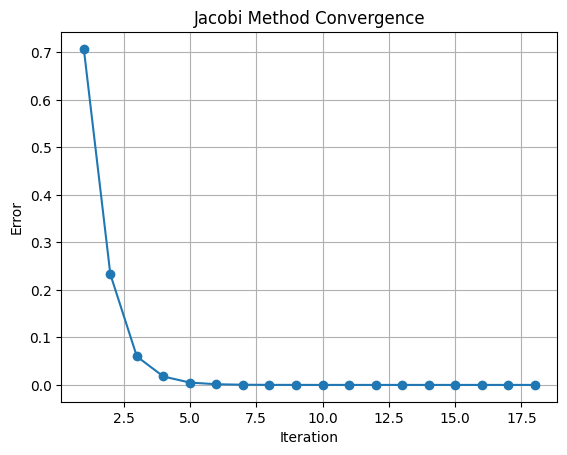

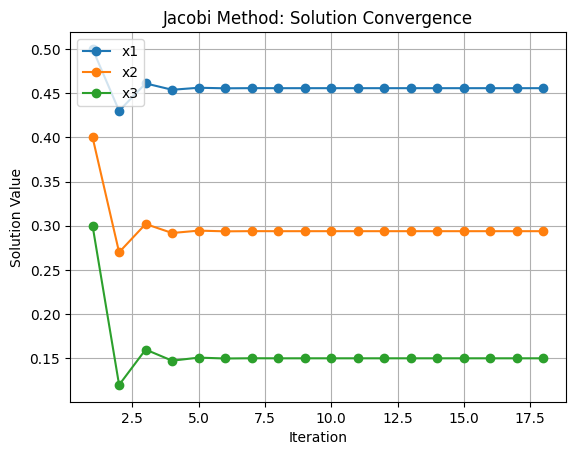

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def diagonally_dominant(A):
    n = len(A)
    for i in range(n):
        diagonal = abs(A[i, i])
        sum_other_elements = 0
        for j in range(n):
            if j != i:
                sum_other_elements += abs(A[i, j])
        if diagonal <= sum_other_elements:
            return False
    return True
def jacobi(A, b, x0, max_iter=70, tol=1e-9):
    n = len(b)
    x = x0.copy()
    errors = []
    solutions = []
    for iteration in range(max_iter):
        x_new = np.zeros(n)
        for i in range(n):
            sum_values = 0
            for j in range(n):
                if j != i:
                    sum_values += A[i, j] * x[j]
            if A[i, i] == 0:
               raise ValueError("Zero diagonal element")
            x_new[i] = (b[i] - sum_values) / A[i, i]
        error = np.linalg.norm(x_new - x)
        errors.append(error)
        solutions.append(x_new.copy())
        print("Iteration:", iteration + 1)
        print("x =", x_new)
        print("Error =", error)
        print()
        if error < tol:
            return x_new, iteration + 1, errors, solutions
        x = x_new
    return x, max_iter, errors, solutions

A = np.array([
    [10, 1, 1],
    [2, 10, 1],
    [2, 2, 10]], dtype=float)
b = np.array([5, 4, 3], dtype=float)
x0 = np.array([0, 0, 0], dtype=float)
print("Diagonal Dominance Check:")
if diagonally_dominant(A):
    print("Matrix is strictly diagonally dominant.")
else:
    print("Matrix is not strictly diagonally dominant.")
x, iterations, errors, solutions = jacobi(A, b, x0)
print("\nFinal Solution using Jacobi:")
print("x =", x)
print("\nNumber of Iterations:")
print(iterations)
print("\nVerification:")
print("A @ x =", A @ x)
print("b =", b)
residual_jacobi = np.linalg.norm(A @ x - b)
print("\nResidual Error using Jacobi:")
print(residual_jacobi)
solutions = np.array(solutions)
# Comparison with NumPy
x_numpy = np.linalg.solve(A, b)
print("\nSolution using NumPy:")
print("x =", x_numpy)
# Difference between Jacobi and NumPy
comparison_error = np.linalg.norm(x - x_numpy)
print("\nDifference between Jacobi and NumPy:")
print(comparison_error)
residual_numpy = np.linalg.norm(A @ x_numpy - b)
print("\nResidual Error using NumPy:")
print(residual_numpy)

# Error vs Iteration Graph
plt.figure()
plt.plot(range(1, len(errors) + 1),
    errors,
    marker='o')
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Jacobi Method Convergence")
plt.grid()
plt.show()
# Solution Values vs Iteration Graph
plt.figure()
plt.plot(range(1, len(solutions) + 1),
    solutions[:, 0],
    marker='o',
    label='x1')
plt.plot( range(1, len(solutions) + 1),
    solutions[:, 1],
    marker='o',
    label='x2')
plt.plot(range(1, len(solutions) + 1),
         solutions[:, 2],marker='o',
         label='x3')
plt.xlabel("Iteration")
plt.ylabel("Solution Value")
plt.title("Jacobi Method: Solution Convergence")
plt.legend()
plt.grid()
plt.show()